# Global Measurement Development Clustering Analysis

#### Life Cycle of Machine Learning Project
* Understanding the Problem Statement
* Data Collection
* Exploratory Data Analysis (EDA)
* Data Pre-processing
* Model Training
* Model Deployment
* Monitoring Performance 

### Business Objective: 
Creating clusters on global development measurement dataset

### Data Set Details:
The dataset has information about important economic and development metrics related to various countries across the globe.


### Variable Description
| Feature Name                        | Description                                                                                                                                                          |
| ----------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Country**                         | Name of the country being analyzed. Used as an identifier for each observation.                                                                                      |
| **Birth Rate**                      | Number of live births per 1,000 people in a year. Indicates population growth trends.                                                                                |
| **Business Tax**                    | Total tax rate (% of commercial profits) paid by businesses including all taxes and contributions.                                                                   |
| **CO2 Emissions**                   | Carbon dioxide emissions per capita (metric tons per person). Reflects environmental impact and industrialization level.                                             |
| **Days to Start Business**          | Average number of days required to legally register and start a business in a country.                                                                               |
| **Ease of Business**                | Index or ranking that measures how easy it is to start and operate a business in a country. Lower rank or higher score usually indicates better business conditions. |
| **Energy Usage**                    | Energy consumption per capita (kg of oil equivalent or kWh per person). Indicates development and industrial activity.                                               |
| **GDP**                             | Gross Domestic Product per capita (usually in USD). Represents economic productivity and wealth.                                                                     |
| **Health Exp % GDP**                | Percentage of GDP spent on healthcare. Shows national investment in health services.                                                                                 |
| **Health Exp/Capita**               | Healthcare expenditure per person (USD). Indicates healthcare quality and accessibility.                                                                             |
| **Hours to Do Tax**                 | Number of hours per year required by businesses to prepare, file, and pay taxes. Reflects administrative burden.                                                     |
| **Infant Mortality**                | Number of infant deaths per 1,000 live births. Indicates healthcare quality and living conditions.                                                                   |
| **Internet Usage**                  | Percentage of population using the internet. Indicates digital development level.                                                                                    |
| **Lending Rate**                    | Bank lending interest rate (%). Represents cost of borrowing money in the economy.                                                                                   |
| **Life Expectancy Female**          | Average number of years a female is expected to live. Reflects healthcare and living standards.                                                                      |
| **Life Expectancy Male**            | Average number of years a male is expected to live. Indicates overall health and development.                                                                        |
| **Mobile Phone Usage**              | Number of mobile phone subscriptions per 100 people. Indicates technological adoption and communication infrastructure.             |
| **Number of Records**               | Count of observations or entries for a country. Often used as a dataset reference or grouping indicator, not useful for clustering. |
| **Population 0-14**                 | Percentage of total population aged between 0 and 14 years. Indicates young population proportion.                                  |
| **Population 15-64**                | Percentage of total population aged between 15 and 64 years. Represents working-age population.                                     |
| **Population 65+**                  | Percentage of total population aged 65 years and above. Indicates aging population trends.                                          |
| **Population Total**                | Total number of people living in a country. Measures country size.                                                                  |
| **Population Urban**                | Percentage of population living in urban areas. Reflects urbanization level.                                                        |
| **Tourism Inbound**                 | Total revenue earned from international tourists (usually in USD). Indicates tourism attractiveness and economic contribution.      |
| **Tourism Outbound**                | Total expenditure by residents traveling abroad (usually in USD). Reflects international travel activity and economic capacity.     |


### Acceptance Criterion: 
Work on different clustering models, do a comparative analysis and need to deploy the clustering application on streamlit, flask etc.


### Import required packages

In [201]:
#!pip install plotly

In [202]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

### Read Dataset

In [203]:
df = pd.read_excel('World_development_mesurement.xlsx')

In [204]:
df.head(5)

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"


In [205]:
df.shape

(2704, 25)

In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   object 
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   object 
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   object 
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Female  2568 non-null   

### Renaming columns to standard naming format

In [207]:
df.columns=(
    df.columns
    .str.strip()
    .str.replace(' ','_')
    .str.replace('+', 'plus')
    .str.replace('/', '_per_')
    .str.replace('%', 'percent')
    .str.replace('-', '_')
)

In [208]:
df.columns

Index(['Birth_Rate', 'Business_Tax_Rate', 'CO2_Emissions', 'Country',
       'Days_to_Start_Business', 'Ease_of_Business', 'Energy_Usage', 'GDP',
       'Health_Exp_percent_GDP', 'Health_Exp_per_Capita', 'Hours_to_do_Tax',
       'Infant_Mortality_Rate', 'Internet_Usage', 'Lending_Interest',
       'Life_Expectancy_Female', 'Life_Expectancy_Male', 'Mobile_Phone_Usage',
       'Number_of_Records', 'Population_0_14', 'Population_15_64',
       'Population_65plus', 'Population_Total', 'Population_Urban',
       'Tourism_Inbound', 'Tourism_Outbound'],
      dtype='object')

In [209]:
#define numerical and categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# printing columns
print('We have {} numerical features : {} \n'.format(len(numeric_features), numeric_features))
print('We have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 19 numerical features : ['Birth_Rate', 'CO2_Emissions', 'Days_to_Start_Business', 'Ease_of_Business', 'Energy_Usage', 'Health_Exp_percent_GDP', 'Hours_to_do_Tax', 'Infant_Mortality_Rate', 'Internet_Usage', 'Lending_Interest', 'Life_Expectancy_Female', 'Life_Expectancy_Male', 'Mobile_Phone_Usage', 'Number_of_Records', 'Population_0_14', 'Population_15_64', 'Population_65plus', 'Population_Total', 'Population_Urban'] 

We have 6 categorical features : ['Business_Tax_Rate', 'Country', 'GDP', 'Health_Exp_per_Capita', 'Tourism_Inbound', 'Tourism_Outbound']


<p style="background-color:#008000;color:#fff;font-size:18px;padding:10px"> Insights : </p>
<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

* First thing lets rename all the columns with proper names with standard naming formatas it contains spaces, and special charcters.
* Out of total 25 features, we have 19 numerical features and 6 categorical features.
* Excluding country as a categorical feature, other five features like GDP, Business Tax Rate, Health Exp/Capita, Tourism Inbound and Tourism Outbound are numerical features, and helpful in analysing the Country growth, their international tourism reveues and expenditures.
* We will remove the currency symbol from these features and convert them into the numerical features and make them useful in getting insights.
    
<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

In [210]:
# Converting the categorical feature into numerical form removing currency symbol, comma and any spaces

cols = ['Business_Tax_Rate', 'GDP', 'Health_Exp_per_Capita', 'Tourism_Inbound', 'Tourism_Outbound']

for col in cols:
    df[col] = df[col].replace('[^0-9.]','',regex=True).astype(float)

In [211]:
#define numerical and categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# printing columns
print('We have {} numerical features : {} \n'.format(len(numeric_features), numeric_features))
print('We have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 24 numerical features : ['Birth_Rate', 'Business_Tax_Rate', 'CO2_Emissions', 'Days_to_Start_Business', 'Ease_of_Business', 'Energy_Usage', 'GDP', 'Health_Exp_percent_GDP', 'Health_Exp_per_Capita', 'Hours_to_do_Tax', 'Infant_Mortality_Rate', 'Internet_Usage', 'Lending_Interest', 'Life_Expectancy_Female', 'Life_Expectancy_Male', 'Mobile_Phone_Usage', 'Number_of_Records', 'Population_0_14', 'Population_15_64', 'Population_65plus', 'Population_Total', 'Population_Urban', 'Tourism_Inbound', 'Tourism_Outbound'] 

We have 1 categorical features : ['Country']


In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth_Rate              2585 non-null   float64
 1   Business_Tax_Rate       1423 non-null   float64
 2   CO2_Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days_to_Start_Business  1718 non-null   float64
 5   Ease_of_Business        185 non-null    float64
 6   Energy_Usage            1785 non-null   float64
 7   GDP                     2494 non-null   float64
 8   Health_Exp_percent_GDP  2395 non-null   float64
 9   Health_Exp_per_Capita   2395 non-null   float64
 10  Hours_to_do_Tax         1416 non-null   float64
 11  Infant_Mortality_Rate   2444 non-null   float64
 12  Internet_Usage          2531 non-null   float64
 13  Lending_Interest        1880 non-null   float64
 14  Life_Expectancy_Female  2568 non-null   

In [213]:
df.head(3)

,Birth_Rate,Business_Tax_Rate,CO2_Emissions,Country,Days_to_Start_Business,Ease_of_Business,Energy_Usage,GDP,Health_Exp_percent_GDP,Health_Exp_per_Capita,...,Life_Expectancy_Male,Mobile_Phone_Usage,Number_of_Records,Population_0_14,Population_15_64,Population_65plus,Population_Total,Population_Urban,Tourism_Inbound,Tourism_Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,5.479006e+10,0.035,60.0,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,102000000.0,193000000.0
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,9.129595e+09,0.034,22.0,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,34000000.0,146000000.0
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,2.359122e+09,0.043,15.0,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,77000000.0,50000000.0


## Univariate Analysis
Understanding the distribution of values for a single variable (Numerical Features)

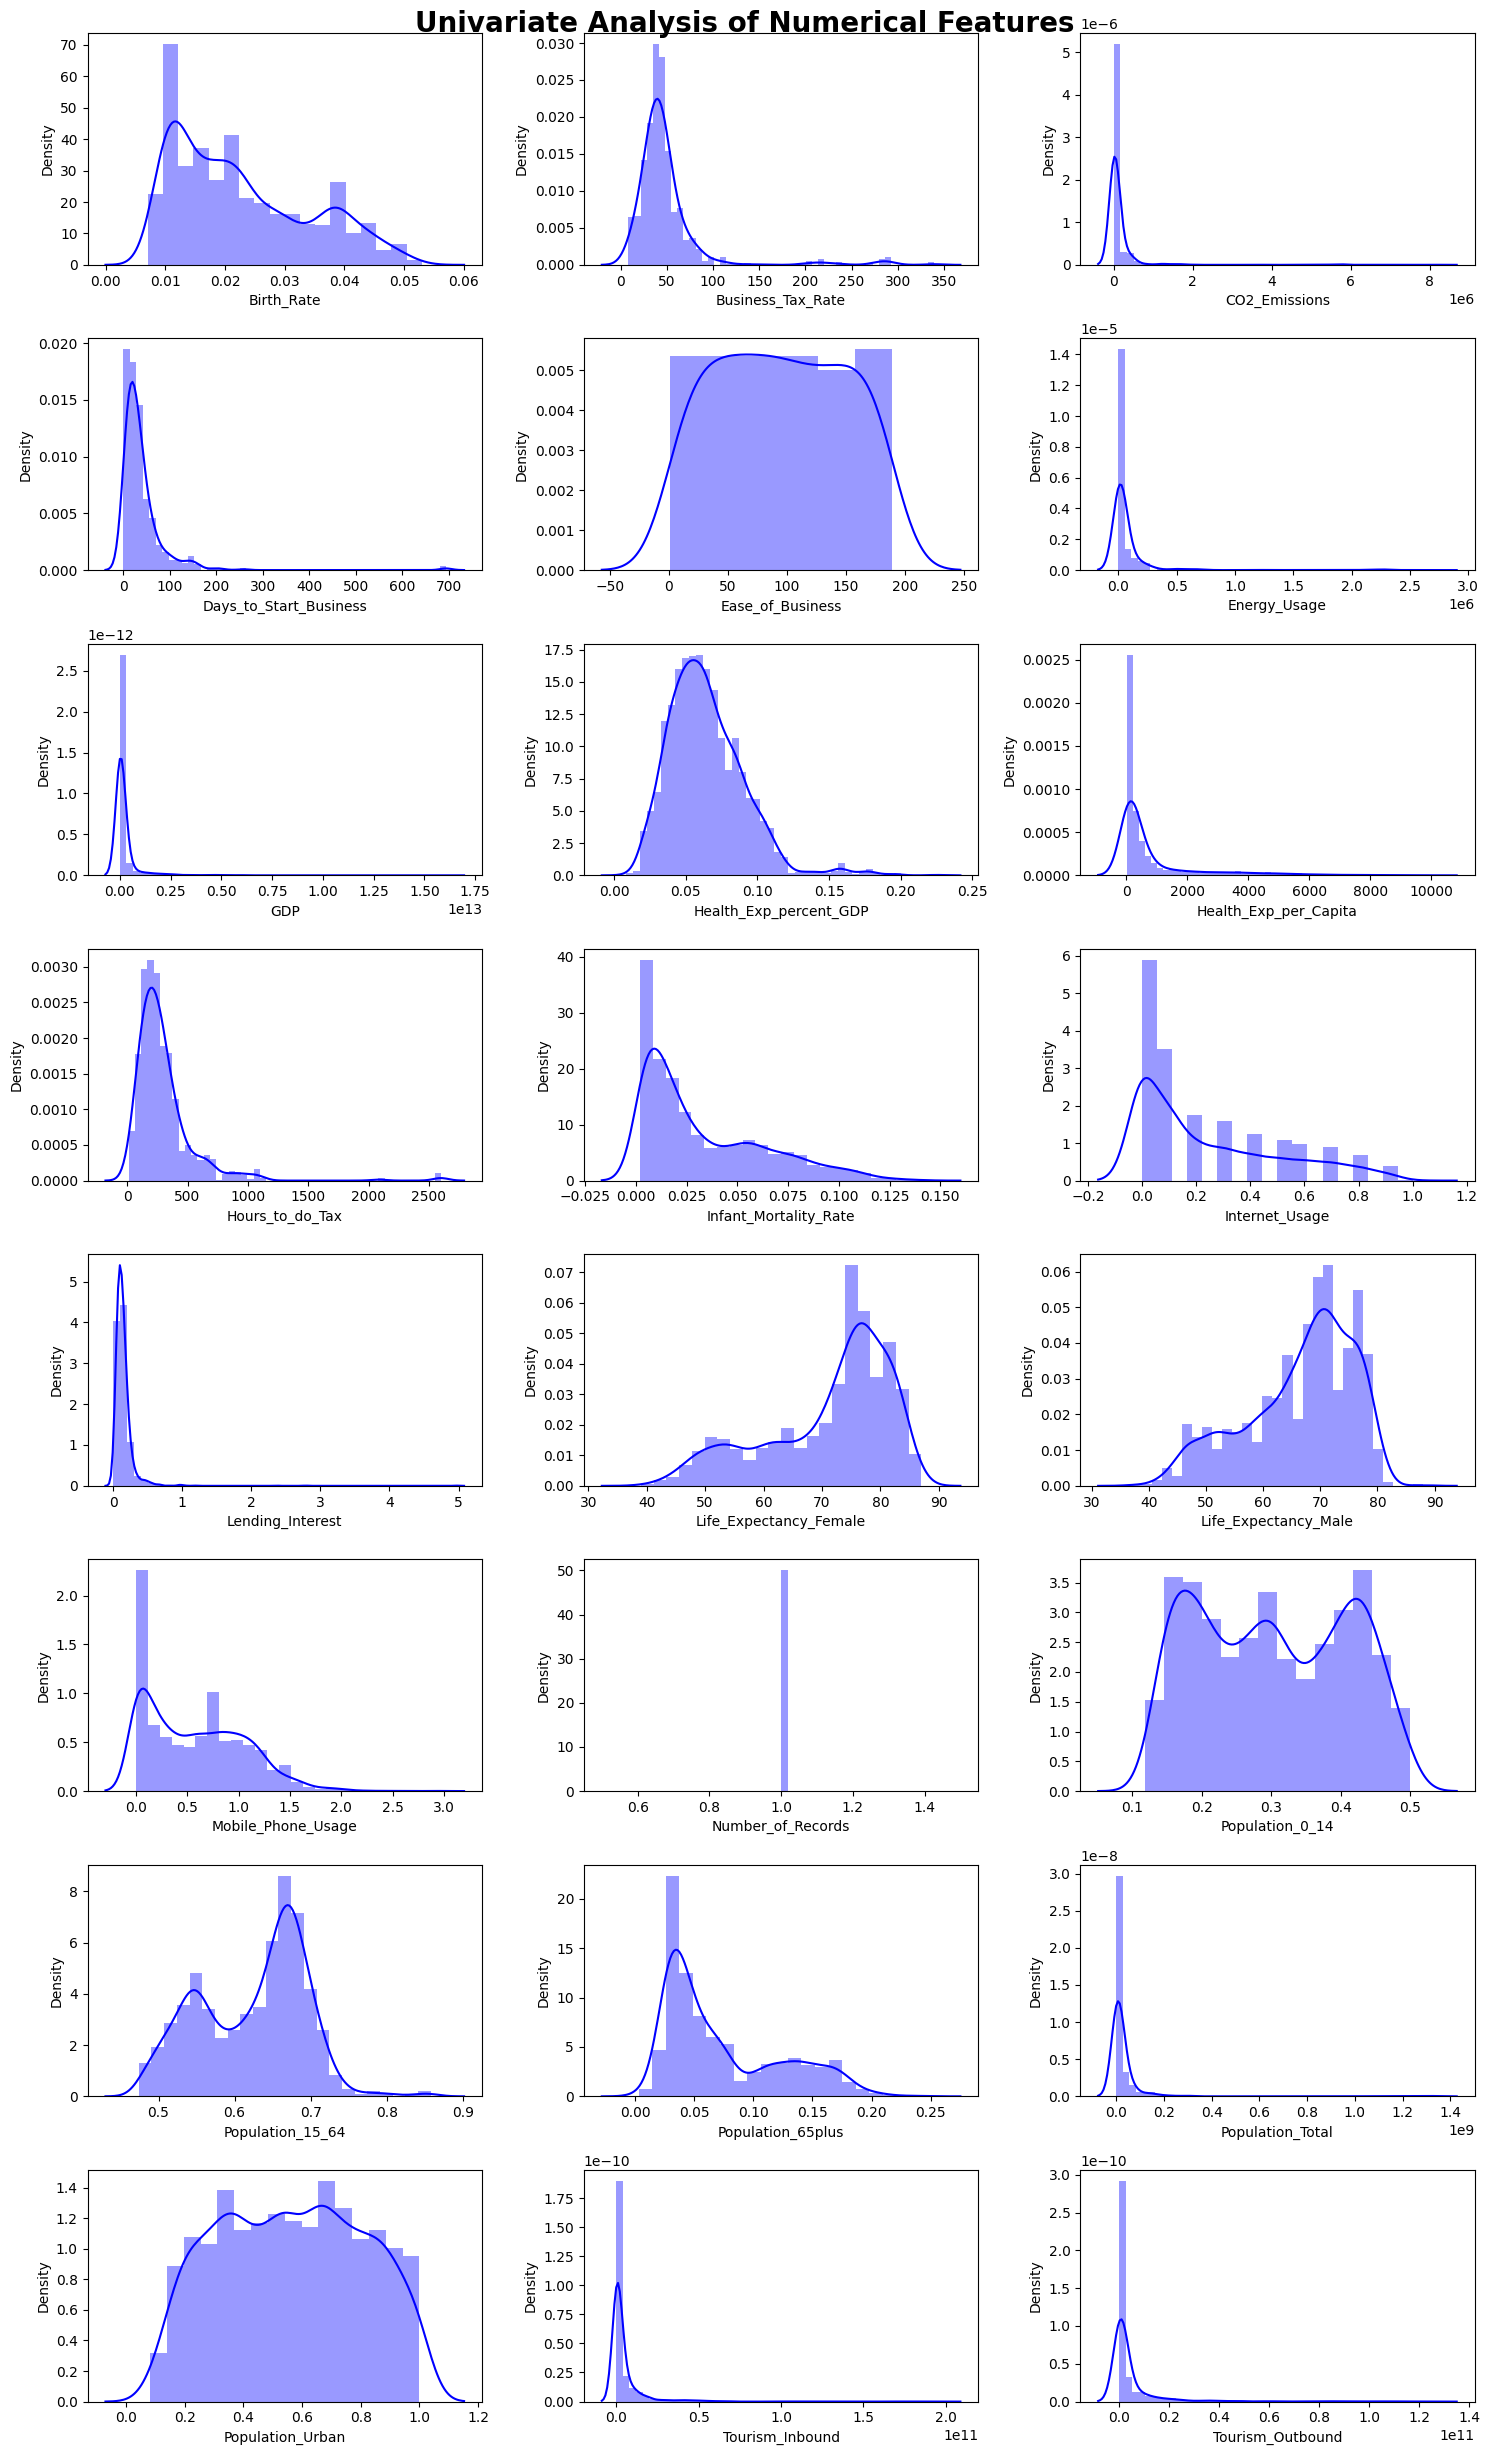

In [214]:
plt.rcParams['figure.figsize'] = (15,25)
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold')

for i in range(0, len(numeric_features)):
    ax=plt.subplot(8, 3, i+1)
    sns.distplot(x=df[numeric_features[i]], color='blue',ax=ax)
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

# Save plot
plt.savefig('./images/Univariate_Num.png')

<p style="background-color:#008000;color:#fff;font-size:18px;padding:10px"> Insights : </p>
<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

* Most numerical features are right-skewed with significant outliers such as GDP, CO2 emissions, population total, energy usage, tourism inbound and tourism outbound.
* A few features like life expectancy male and female, Health Exp % GDP and health expenditure follow near-normal distributions.
* Most of the features are right skewed, requires scaling or log transformation before model training.
* The feature NUmber of records has no variance, we can drop this feature.
    
<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

### Dropping Catgorical feature country and NUmber of records having no variance

In [215]:
df.drop(columns=['Country', 'Number_of_Records'], inplace=True)

In [216]:
df.nunique()

Birth_Rate                  47
Business_Tax_Rate          447
CO2_Emissions             1743
Days_to_Start_Business     126
Ease_of_Business           185
Energy_Usage              1721
GDP                       2494
Health_Exp_percent_GDP     145
Health_Exp_per_Capita     1069
Hours_to_do_Tax            280
Infant_Mortality_Rate      129
Internet_Usage              11
Lending_Interest           351
Life_Expectancy_Female      49
Life_Expectancy_Male        47
Mobile_Phone_Usage          26
Population_0_14            376
Population_15_64           298
Population_65plus          208
Population_Total          2699
Population_Urban           822
Tourism_Inbound           1650
Tourism_Outbound          1457
dtype: int64

## Multivariate Analysis
#### Check Multicolinearity in Numerical Features

In [217]:
df[(list(df.columns)[1:])].corr(numeric_only=True)

,Business_Tax_Rate,CO2_Emissions,Days_to_Start_Business,Ease_of_Business,Energy_Usage,GDP,Health_Exp_percent_GDP,Health_Exp_per_Capita,Hours_to_do_Tax,Infant_Mortality_Rate,...,Life_Expectancy_Female,Life_Expectancy_Male,Mobile_Phone_Usage,Population_0_14,Population_15_64,Population_65plus,Population_Total,Population_Urban,Tourism_Inbound,Tourism_Outbound
Business_Tax_Rate,1.000000,0.022298,0.013339,0.287221,0.059210,0.005880,0.034727,-0.110941,0.138647,0.341270,...,-0.284273,-0.312970,-0.233985,0.218907,-0.258508,-0.106498,0.058711,-0.123177,-0.017257,-0.021214
CO2_Emissions,0.022298,1.000000,-0.055666,NaN,0.988715,0.801876,0.163236,0.254039,0.081485,-0.135421,...,0.135219,0.141452,0.054400,-0.198328,0.190808,0.160403,0.721145,0.098051,0.696357,0.650080
Days_to_Start_Business,0.013339,-0.055666,1.000000,0.308789,-0.069418,-0.079282,-0.147686,-0.181849,0.148423,0.200082,...,-0.197764,-0.213764,-0.199868,0.203978,-0.166224,-0.201973,0.001357,-0.092493,-0.122206,-0.117471
Ease_of_Business,0.287221,NaN,0.308789,1.000000,-0.234867,-0.227305,-0.278061,-0.573508,0.346213,0.731639,...,-0.709671,-0.706122,-0.582954,0.741035,-0.631452,-0.646456,0.029175,-0.493255,-0.339292,-0.314160
Energy_Usage,0.059210,0.988715,-0.069418,-0.234867,1.000000,0.861041,0.253146,0.278551,0.074673,-0.120019,...,0.125224,0.132984,0.045198,-0.184007,0.171528,0.148971,0.677971,0.094218,0.742379,0.703488
GDP,0.005880,0.801876,-0.079282,-0.227305,0.861041,1.000000,0.329416,0.451492,0.030371,-0.178879,...,0.196762,0.207653,0.129847,-0.234099,0.161611,0.275494,0.379295,0.185874,0.879849,0.856945
Health_Exp_percent_GDP,0.034727,0.163236,-0.147686,-0.278061,0.253146,0.329416,1.000000,0.444986,-0.079755,-0.165117,...,0.208335,0.219441,0.187336,-0.292266,0.093604,0.489835,-0.054097,0.205994,0.379051,0.371141
Health_Exp_per_Capita,-0.110941,0.254039,-0.181849,-0.573508,0.278551,0.451492,0.444986,1.000000,-0.213454,-0.452413,...,0.499595,0.540419,0.460803,-0.529232,0.362444,0.623775,-0.005934,0.520300,0.556093,0.579977
Hours_to_do_Tax,0.138647,0.081485,0.148423,0.346213,0.074673,0.030371,-0.079755,-0.213454,1.000000,0.133808,...,-0.104772,-0.154317,-0.103461,0.075677,-0.084376,-0.043624,0.146920,0.010022,-0.058792,-0.040801
Infant_Mortality_Rate,0.341270,-0.135421,0.200082,0.731639,-0.120019,-0.178879,-0.165117,-0.452413,0.133808,1.000000,...,-0.933001,-0.912240,-0.599383,0.822479,-0.798960,-0.649284,0.006897,-0.619742,-0.262693,-0.267785


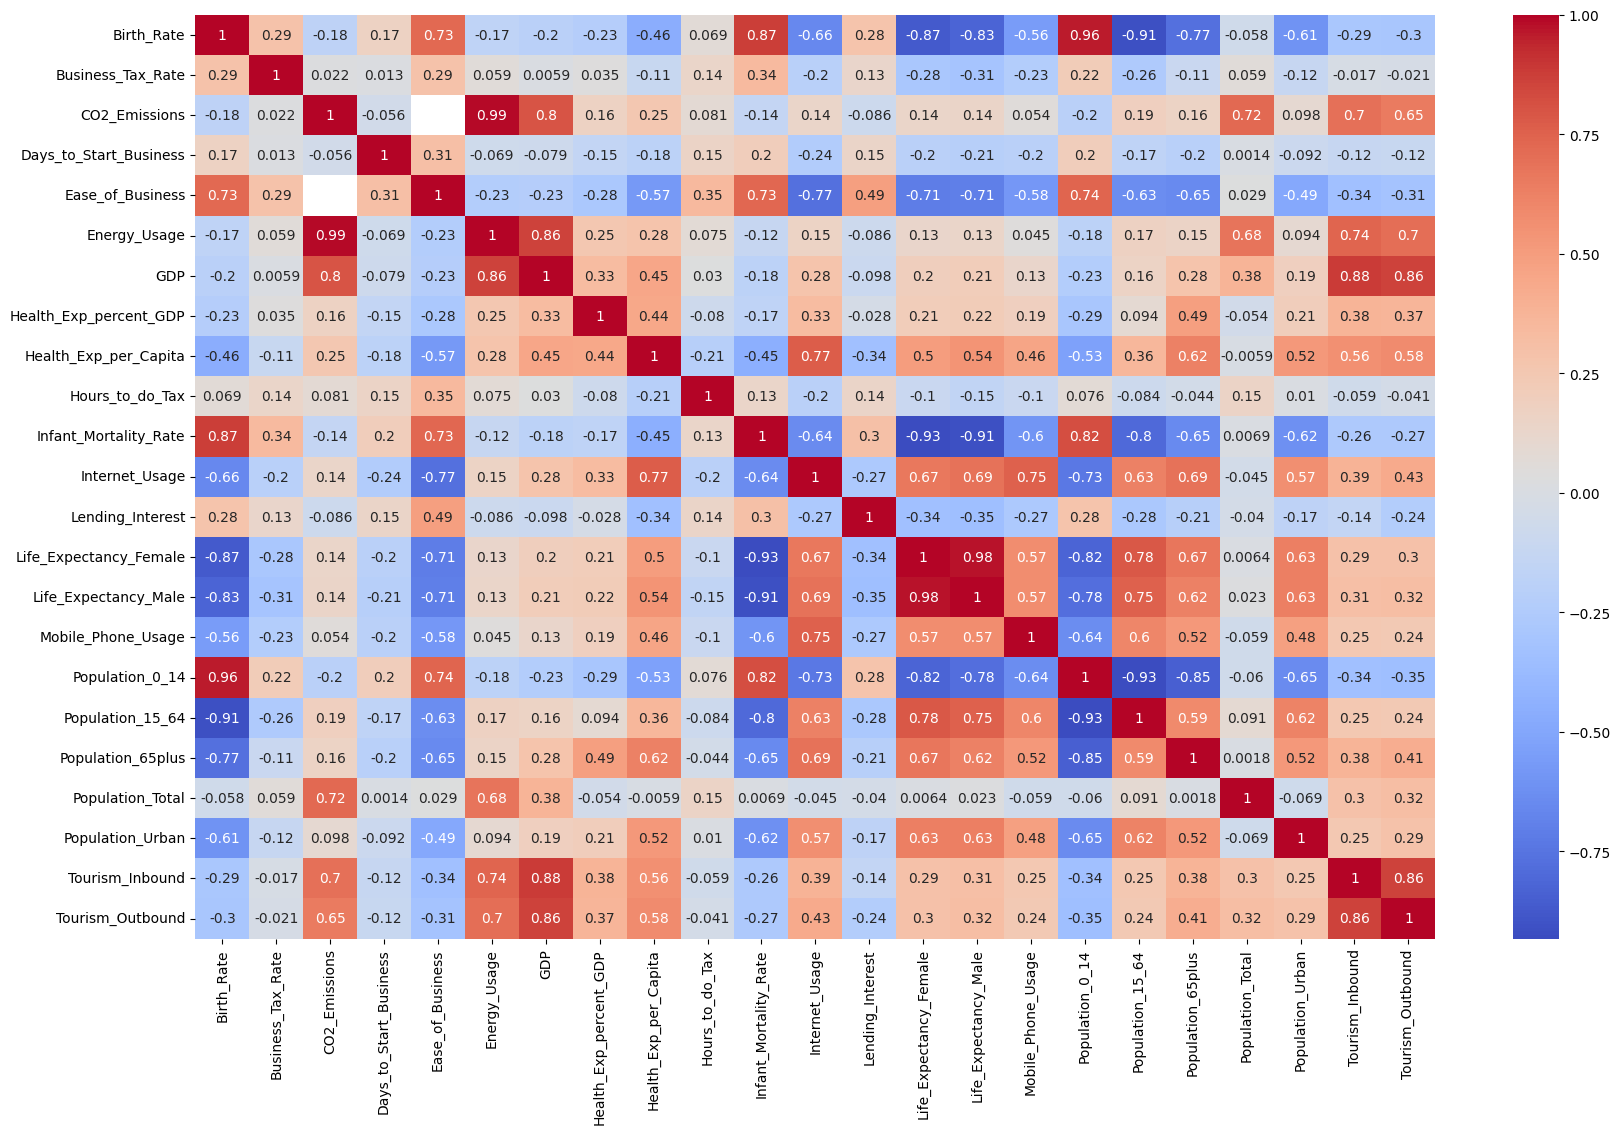

<Figure size 1500x2500 with 0 Axes>

In [218]:
plt.figure(figsize = (20,12))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True)
plt.show()

#Save plot
plt.savefig('./images/Multivariate_Analysis_Correlation_Heatmap.png')

<p style="background-color:#008000;color:#fff;font-size:18px;padding:10px"> Insights : </p>
<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

* GDP, Co2 Emission, Energy usage are highly co-related, but clustering uses distance calculations, so droping highly co related features may affect loosing partial economy information.
* So better we will make use of Principle Component Anaysis (PCA) to reduce the combine the informations by reducing the features, which will retain most of the information.
* Co2 Emissions and Energy usage are highly co related with arounf 0.99 score, keeps almost same information, which will create noise, so we will drop one feature,before PCA.
* Life Expectancy Male and Life Expectancy Female also having around 0.98 higher co relation, we will drop one.
* Other features dont have much colinearity.
    
<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

## Statistical Summary

In [241]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Birth_Rate,2585.0,2.271489e-02,1.133843e-02,7.000000e-03,1.300000e-02,2.000000e-02,3.100000e-02,5.300000e-02
Business_Tax_Rate,1423.0,4.896690e+01,4.095412e+01,8.200000e+00,3.240000e+01,4.100000e+01,5.155000e+01,3.391000e+02
CO2_Emissions,2125.0,1.423071e+05,6.159288e+05,7.000000e+00,1.360000e+03,8.529000e+03,5.910800e+04,8.286892e+06
Days_to_Start_Business,1718.0,3.999942e+01,5.731859e+01,1.000000e+00,1.300000e+01,2.600000e+01,4.500000e+01,6.940000e+02
Energy_Usage,1785.0,7.723684e+04,2.599239e+05,8.000000e+00,3.737000e+03,1.433800e+04,4.185200e+04,2.727728e+06
GDP,2494.0,2.638540e+11,1.129910e+12,6.310127e+07,3.539042e+09,1.507975e+10,1.102047e+11,1.624460e+13
Health_Exp_percent_GDP,2395.0,6.416952e-02,2.632460e-02,8.000000e-03,4.600000e-02,6.100000e-02,7.900000e-02,2.250000e-01
Health_Exp_per_Capita,2395.0,8.013971e+02,1.473448e+03,2.000000e+00,5.000000e+01,1.930000e+02,6.650000e+02,9.908000e+03
Hours_to_do_Tax,1416.0,3.020685e+02,2.732997e+02,1.200000e+01,1.560000e+02,2.390000e+02,3.447500e+02,2.600000e+03
Infant_Mortality_Rate,2444.0,3.281301e-02,2.996760e-02,2.000000e-03,9.000000e-03,2.000000e-02,5.300000e-02,1.410000e-01


<p style="background-color:#008000;color:#fff;font-size:18px;padding:10px"> Insights : </p>
<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

* Huge difference between median and max, indicates right-skewed distribution.
* Several features are highly skewed
* Many features have very large ranges
* There is presence of outiers
* Presence of missing values 
    
<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

## Checking Null Values and duplicates

In [219]:
df[df.duplicated()]

,Birth_Rate,Business_Tax_Rate,CO2_Emissions,Days_to_Start_Business,Ease_of_Business,Energy_Usage,GDP,Health_Exp_percent_GDP,Health_Exp_per_Capita,Hours_to_do_Tax,...,Life_Expectancy_Female,Life_Expectancy_Male,Mobile_Phone_Usage,Population_0_14,Population_15_64,Population_65plus,Population_Total,Population_Urban,Tourism_Inbound,Tourism_Outbound


In [220]:
df.isnull().sum()

Birth_Rate                 119
Business_Tax_Rate         1281
CO2_Emissions              579
Days_to_Start_Business     986
Ease_of_Business          2519
Energy_Usage               919
GDP                        210
Health_Exp_percent_GDP     309
Health_Exp_per_Capita      309
Hours_to_do_Tax           1288
Infant_Mortality_Rate      260
Internet_Usage             173
Lending_Interest           824
Life_Expectancy_Female     136
Life_Expectancy_Male       136
Mobile_Phone_Usage         167
Population_0_14            220
Population_15_64           220
Population_65plus          220
Population_Total             0
Population_Urban            26
Tourism_Inbound            368
Tourism_Outbound           471
dtype: int64

In [221]:
## Checking Null values percentage
(df.isnull().sum()/len(df))*100

Birth_Rate                 4.400888
Business_Tax_Rate         47.374260
CO2_Emissions             21.412722
Days_to_Start_Business    36.464497
Ease_of_Business          93.158284
Energy_Usage              33.986686
GDP                        7.766272
Health_Exp_percent_GDP    11.427515
Health_Exp_per_Capita     11.427515
Hours_to_do_Tax           47.633136
Infant_Mortality_Rate      9.615385
Internet_Usage             6.397929
Lending_Interest          30.473373
Life_Expectancy_Female     5.029586
Life_Expectancy_Male       5.029586
Mobile_Phone_Usage         6.176036
Population_0_14            8.136095
Population_15_64           8.136095
Population_65plus          8.136095
Population_Total           0.000000
Population_Urban           0.961538
Tourism_Inbound           13.609467
Tourism_Outbound          17.418639
dtype: float64

<p style="background-color:#008000;color:#fff;font-size:18px;padding:10px"> Insights : </p>
<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

* No duplicates available in the dataset
* There are huge number of null values available in dataset, excluding population_total each feature contains missing values.
* Ease_of_Business have higher number of missing values around ~93% missing values, so we will drop this column
* Due to the higher number of missing values in each column we will impute these with simple median imputation or KNN imputation
* We choose median over mean as the data is skewed, if the median imputation is selected.
    
<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

## Simple Imputer (Median) Vs KNN Imputer
#### Computing best imputation results we will pick best imputation method

In [222]:
df.drop(columns=['Ease_of_Business'], inplace=True)

#### Checking with Simple median imputation, as we have skewed data

In [224]:
from sklearn.impute import SimpleImputer

med_imputer = SimpleImputer(strategy='median')

med_imputed = med_imputer.fit_transform(df)

In [228]:
med_imputed = pd.DataFrame(med_imputed, columns=df.columns)

In [229]:
med_imputed.head()

,Birth_Rate,Business_Tax_Rate,CO2_Emissions,Days_to_Start_Business,Energy_Usage,GDP,Health_Exp_percent_GDP,Health_Exp_per_Capita,Hours_to_do_Tax,Infant_Mortality_Rate,...,Life_Expectancy_Female,Life_Expectancy_Male,Mobile_Phone_Usage,Population_0_14,Population_15_64,Population_65plus,Population_Total,Population_Urban,Tourism_Inbound,Tourism_Outbound
0,0.020,41.0,87931.0,26.0,26998.0,5.479006e+10,0.035,60.0,239.0,0.034,...,71.0,67.0,0.0,0.342,0.619,0.039,31719449.0,0.599,102000000.0,193000000.0
1,0.050,41.0,9542.0,26.0,7499.0,9.129595e+09,0.034,22.0,239.0,0.128,...,47.0,44.0,0.0,0.476,0.499,0.025,13924930.0,0.324,34000000.0,146000000.0
2,0.043,41.0,1617.0,26.0,1983.0,2.359122e+09,0.043,15.0,239.0,0.090,...,57.0,53.0,0.0,0.454,0.517,0.029,6949366.0,0.383,77000000.0,50000000.0
3,0.027,41.0,4276.0,26.0,1836.0,5.788312e+09,0.047,152.0,239.0,0.054,...,52.0,49.0,0.1,0.383,0.587,0.029,1755375.0,0.532,227000000.0,209000000.0
4,0.046,41.0,1041.0,26.0,14338.0,2.610959e+09,0.051,12.0,239.0,0.096,...,52.0,49.0,0.0,0.468,0.505,0.028,11607944.0,0.178,23000000.0,30000000.0


##### Checking with KNN imputation

In [227]:
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5)

knn_imputed = knn_imputer.fit_transform(df)

In [231]:
knn_imputed = pd.DataFrame(knn_imputed, columns=df.columns)

In [232]:
knn_imputed.head()

,Birth_Rate,Business_Tax_Rate,CO2_Emissions,Days_to_Start_Business,Energy_Usage,GDP,Health_Exp_percent_GDP,Health_Exp_per_Capita,Hours_to_do_Tax,Infant_Mortality_Rate,...,Life_Expectancy_Female,Life_Expectancy_Male,Mobile_Phone_Usage,Population_0_14,Population_15_64,Population_65plus,Population_Total,Population_Urban,Tourism_Inbound,Tourism_Outbound
0,0.020,50.96,87931.0,29.6,26998.0,5.479006e+10,0.035,60.0,335.4,0.034,...,71.0,67.0,0.0,0.342,0.619,0.039,31719449.0,0.599,102000000.0,193000000.0
1,0.050,43.82,9542.0,30.4,7499.0,9.129595e+09,0.034,22.0,229.8,0.128,...,47.0,44.0,0.0,0.476,0.499,0.025,13924930.0,0.324,34000000.0,146000000.0
2,0.043,45.18,1617.0,58.2,1983.0,2.359122e+09,0.043,15.0,230.6,0.090,...,57.0,53.0,0.0,0.454,0.517,0.029,6949366.0,0.383,77000000.0,50000000.0
3,0.027,38.16,4276.0,47.0,1836.0,5.788312e+09,0.047,152.0,208.4,0.054,...,52.0,49.0,0.1,0.383,0.587,0.029,1755375.0,0.532,227000000.0,209000000.0
4,0.046,88.26,1041.0,32.4,16080.6,2.610959e+09,0.051,12.0,259.4,0.096,...,52.0,49.0,0.0,0.468,0.505,0.028,11607944.0,0.178,23000000.0,30000000.0


In [233]:
missing_before = df.isnull().sum()
missing_after_med = med_imputed.isnull().sum()
missing_after_knn = knn_imputed.isnull().sum()

comparison = pd.DataFrame({
    'Before': missing_before,
    'After Median': missing_after_med,
    'After KNN' : missing_after_knn   
})

comparison

,Before,After Median,After KNN
Birth_Rate,119,0,0
Business_Tax_Rate,1281,0,0
CO2_Emissions,579,0,0
Days_to_Start_Business,986,0,0
Energy_Usage,919,0,0
GDP,210,0,0
Health_Exp_percent_GDP,309,0,0
Health_Exp_per_Capita,309,0,0
Hours_to_do_Tax,1288,0,0
Infant_Mortality_Rate,260,0,0


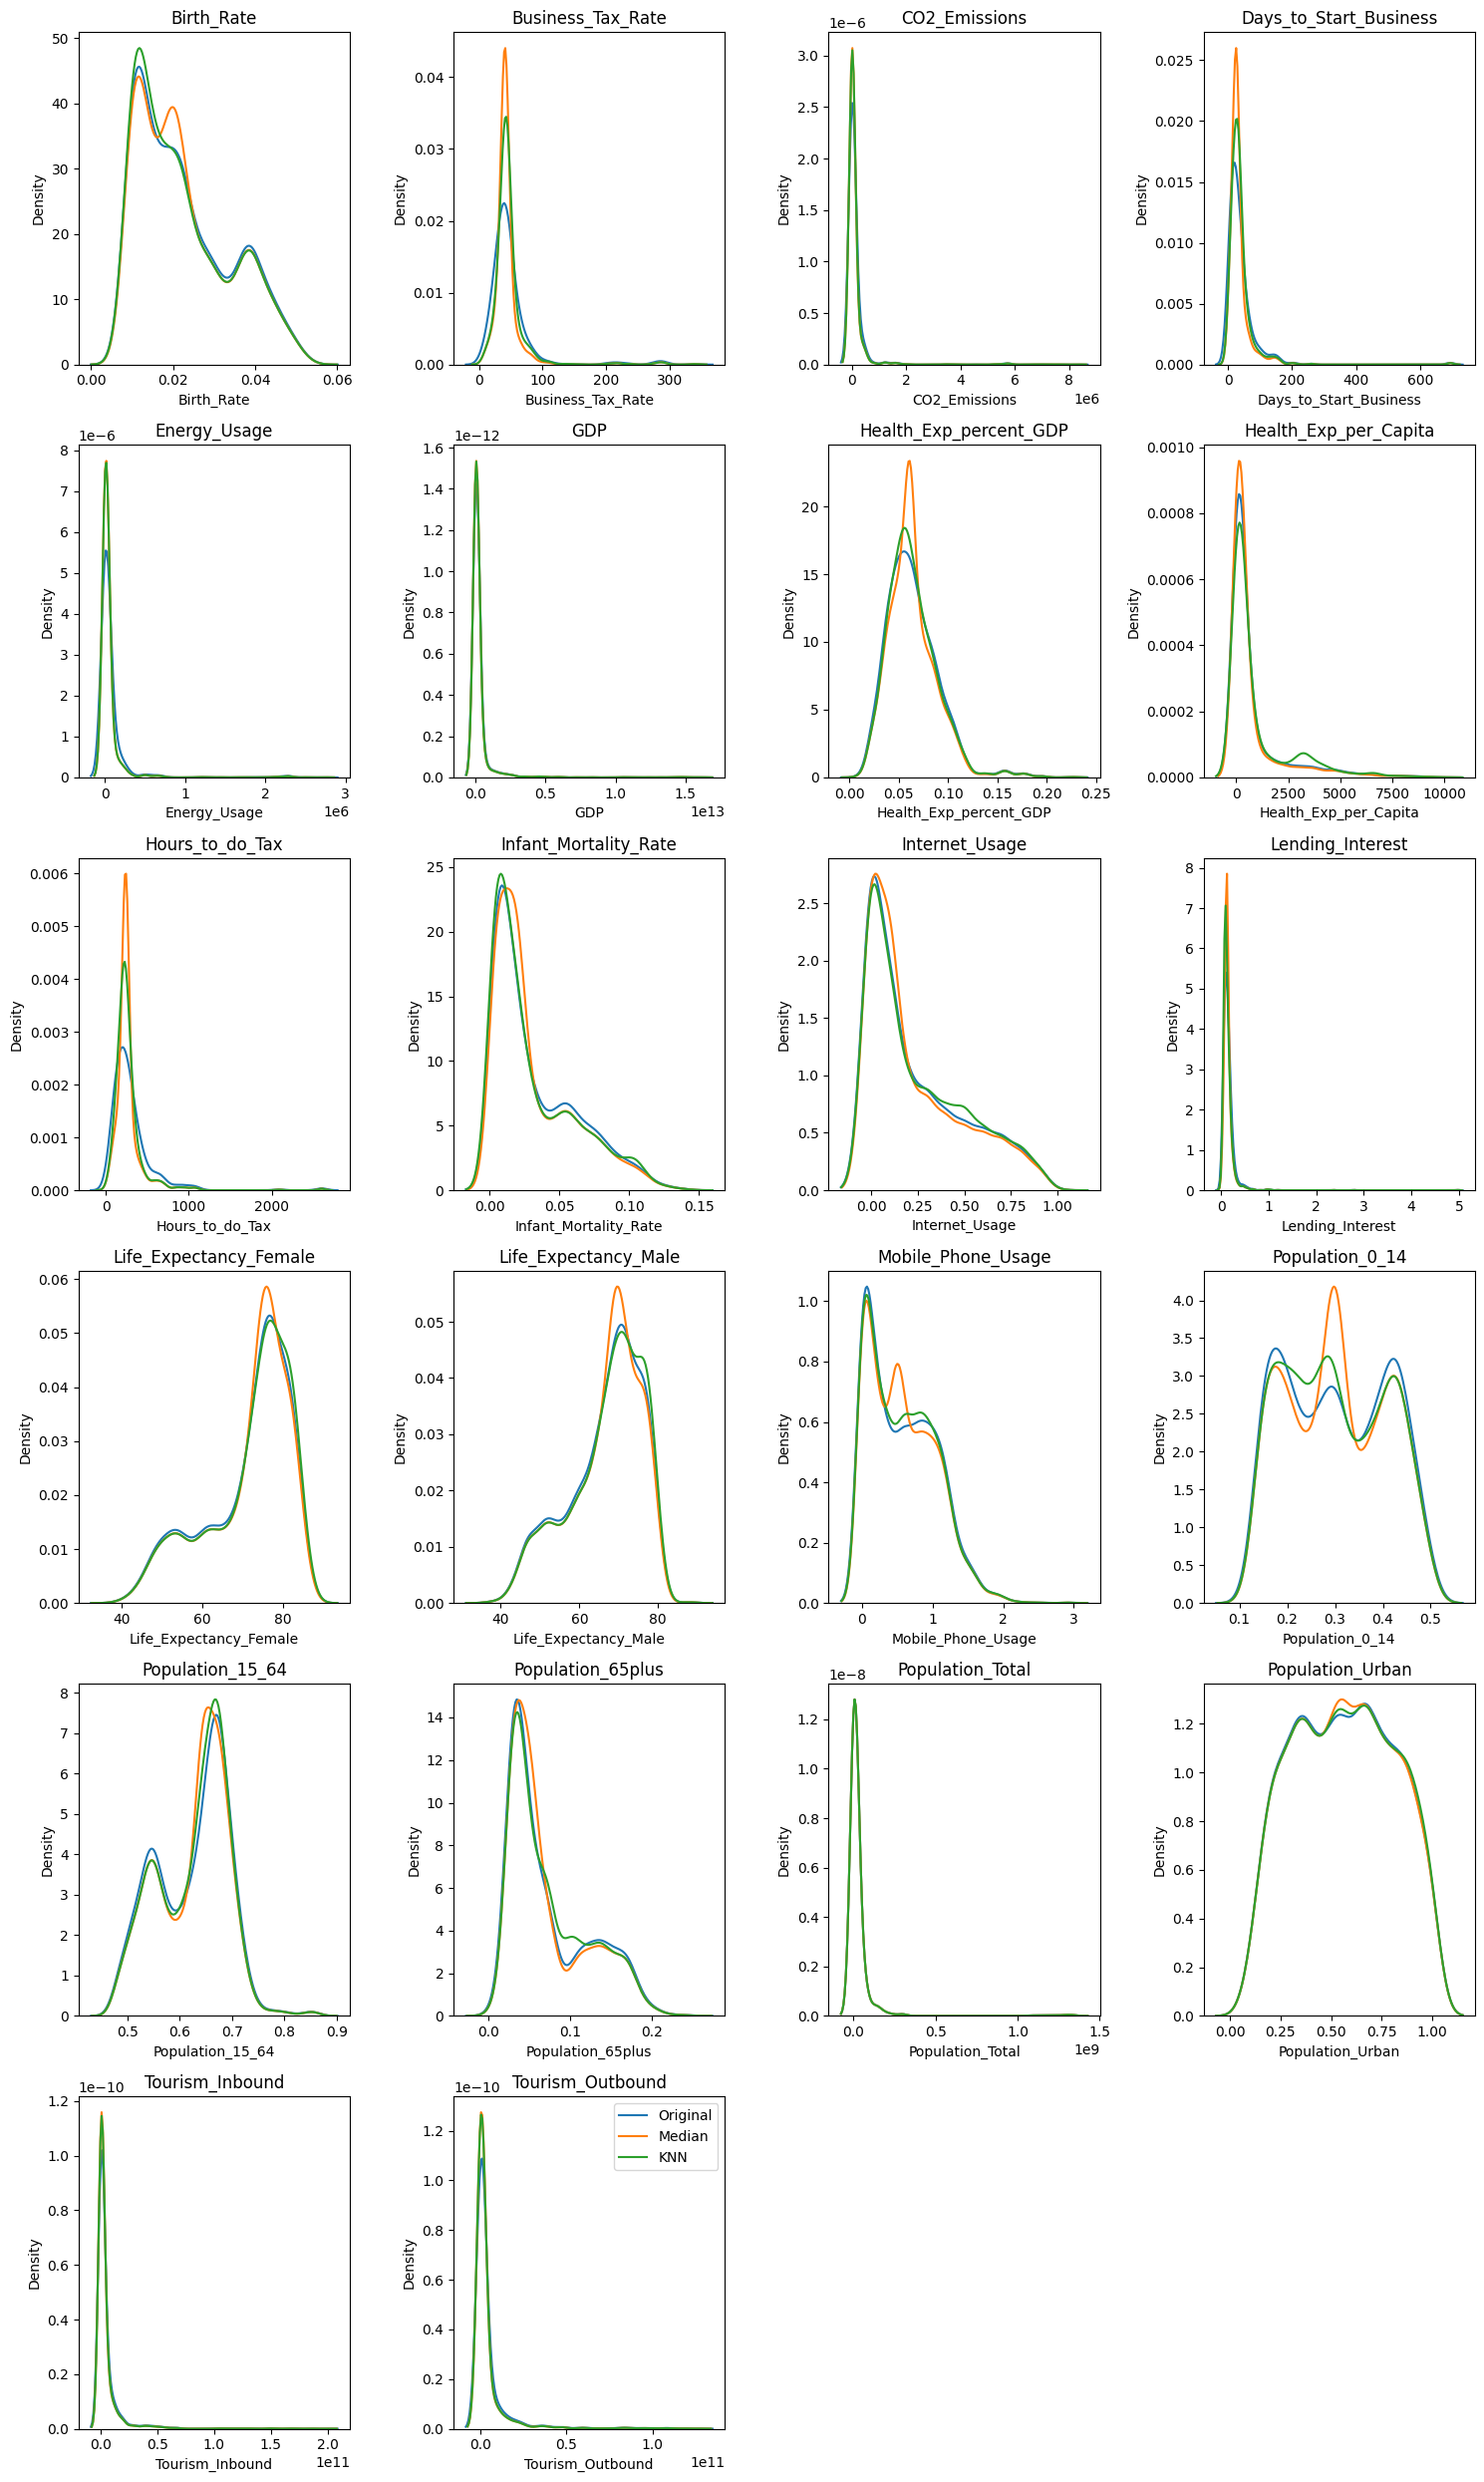

In [234]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']

plt.figure(figsize=(15,25))

for i, feature in enumerate(numeric_features):

    plt.subplot(6,4,i+1)

    sns.kdeplot(df[feature].dropna(), label='Original')
    sns.kdeplot(med_imputed[feature], label='Median')
    sns.kdeplot(knn_imputed[feature], label='KNN')

    plt.title(feature)

plt.tight_layout()
plt.legend()

# Save Plot
plt.savefig('./images/Imputation_comparison.png')

<p style="background-color:#008000;color:#fff;font-size:18px;padding:10px"> Insights : </p>
<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

* After comparing the Simple Median Imputer and KNN Imputer with original kde plots
* Simple Median Imputer changed some of the distributions of data in some features, It is sensitive to outliers.
* The spikes are changed in some charts with median imputer (Orange Curves)
* Whereas KKN imputer performs smooth curves (Green Curves) follwing no more data change, quite natural and similar to orginal curves (Blue Curves)
* So We will select the KNN Imputer** for imputation on the original dataframe.
* **Finalized Imputer : KNN Imputer after comparison.**
  
<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

In [236]:
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5)

df_imputed = knn_imputer.fit_transform(df)

In [237]:
df_imputed = pd.DataFrame(knn_imputed, columns=df.columns)

In [239]:
df_imputed.head(3)

,Birth_Rate,Business_Tax_Rate,CO2_Emissions,Days_to_Start_Business,Energy_Usage,GDP,Health_Exp_percent_GDP,Health_Exp_per_Capita,Hours_to_do_Tax,Infant_Mortality_Rate,...,Life_Expectancy_Female,Life_Expectancy_Male,Mobile_Phone_Usage,Population_0_14,Population_15_64,Population_65plus,Population_Total,Population_Urban,Tourism_Inbound,Tourism_Outbound
0,0.020,50.96,87931.0,29.6,26998.0,5.479006e+10,0.035,60.0,335.4,0.034,...,71.0,67.0,0.0,0.342,0.619,0.039,31719449.0,0.599,102000000.0,193000000.0
1,0.050,43.82,9542.0,30.4,7499.0,9.129595e+09,0.034,22.0,229.8,0.128,...,47.0,44.0,0.0,0.476,0.499,0.025,13924930.0,0.324,34000000.0,146000000.0
2,0.043,45.18,1617.0,58.2,1983.0,2.359122e+09,0.043,15.0,230.6,0.090,...,57.0,53.0,0.0,0.454,0.517,0.029,6949366.0,0.383,77000000.0,50000000.0


# Visualization 

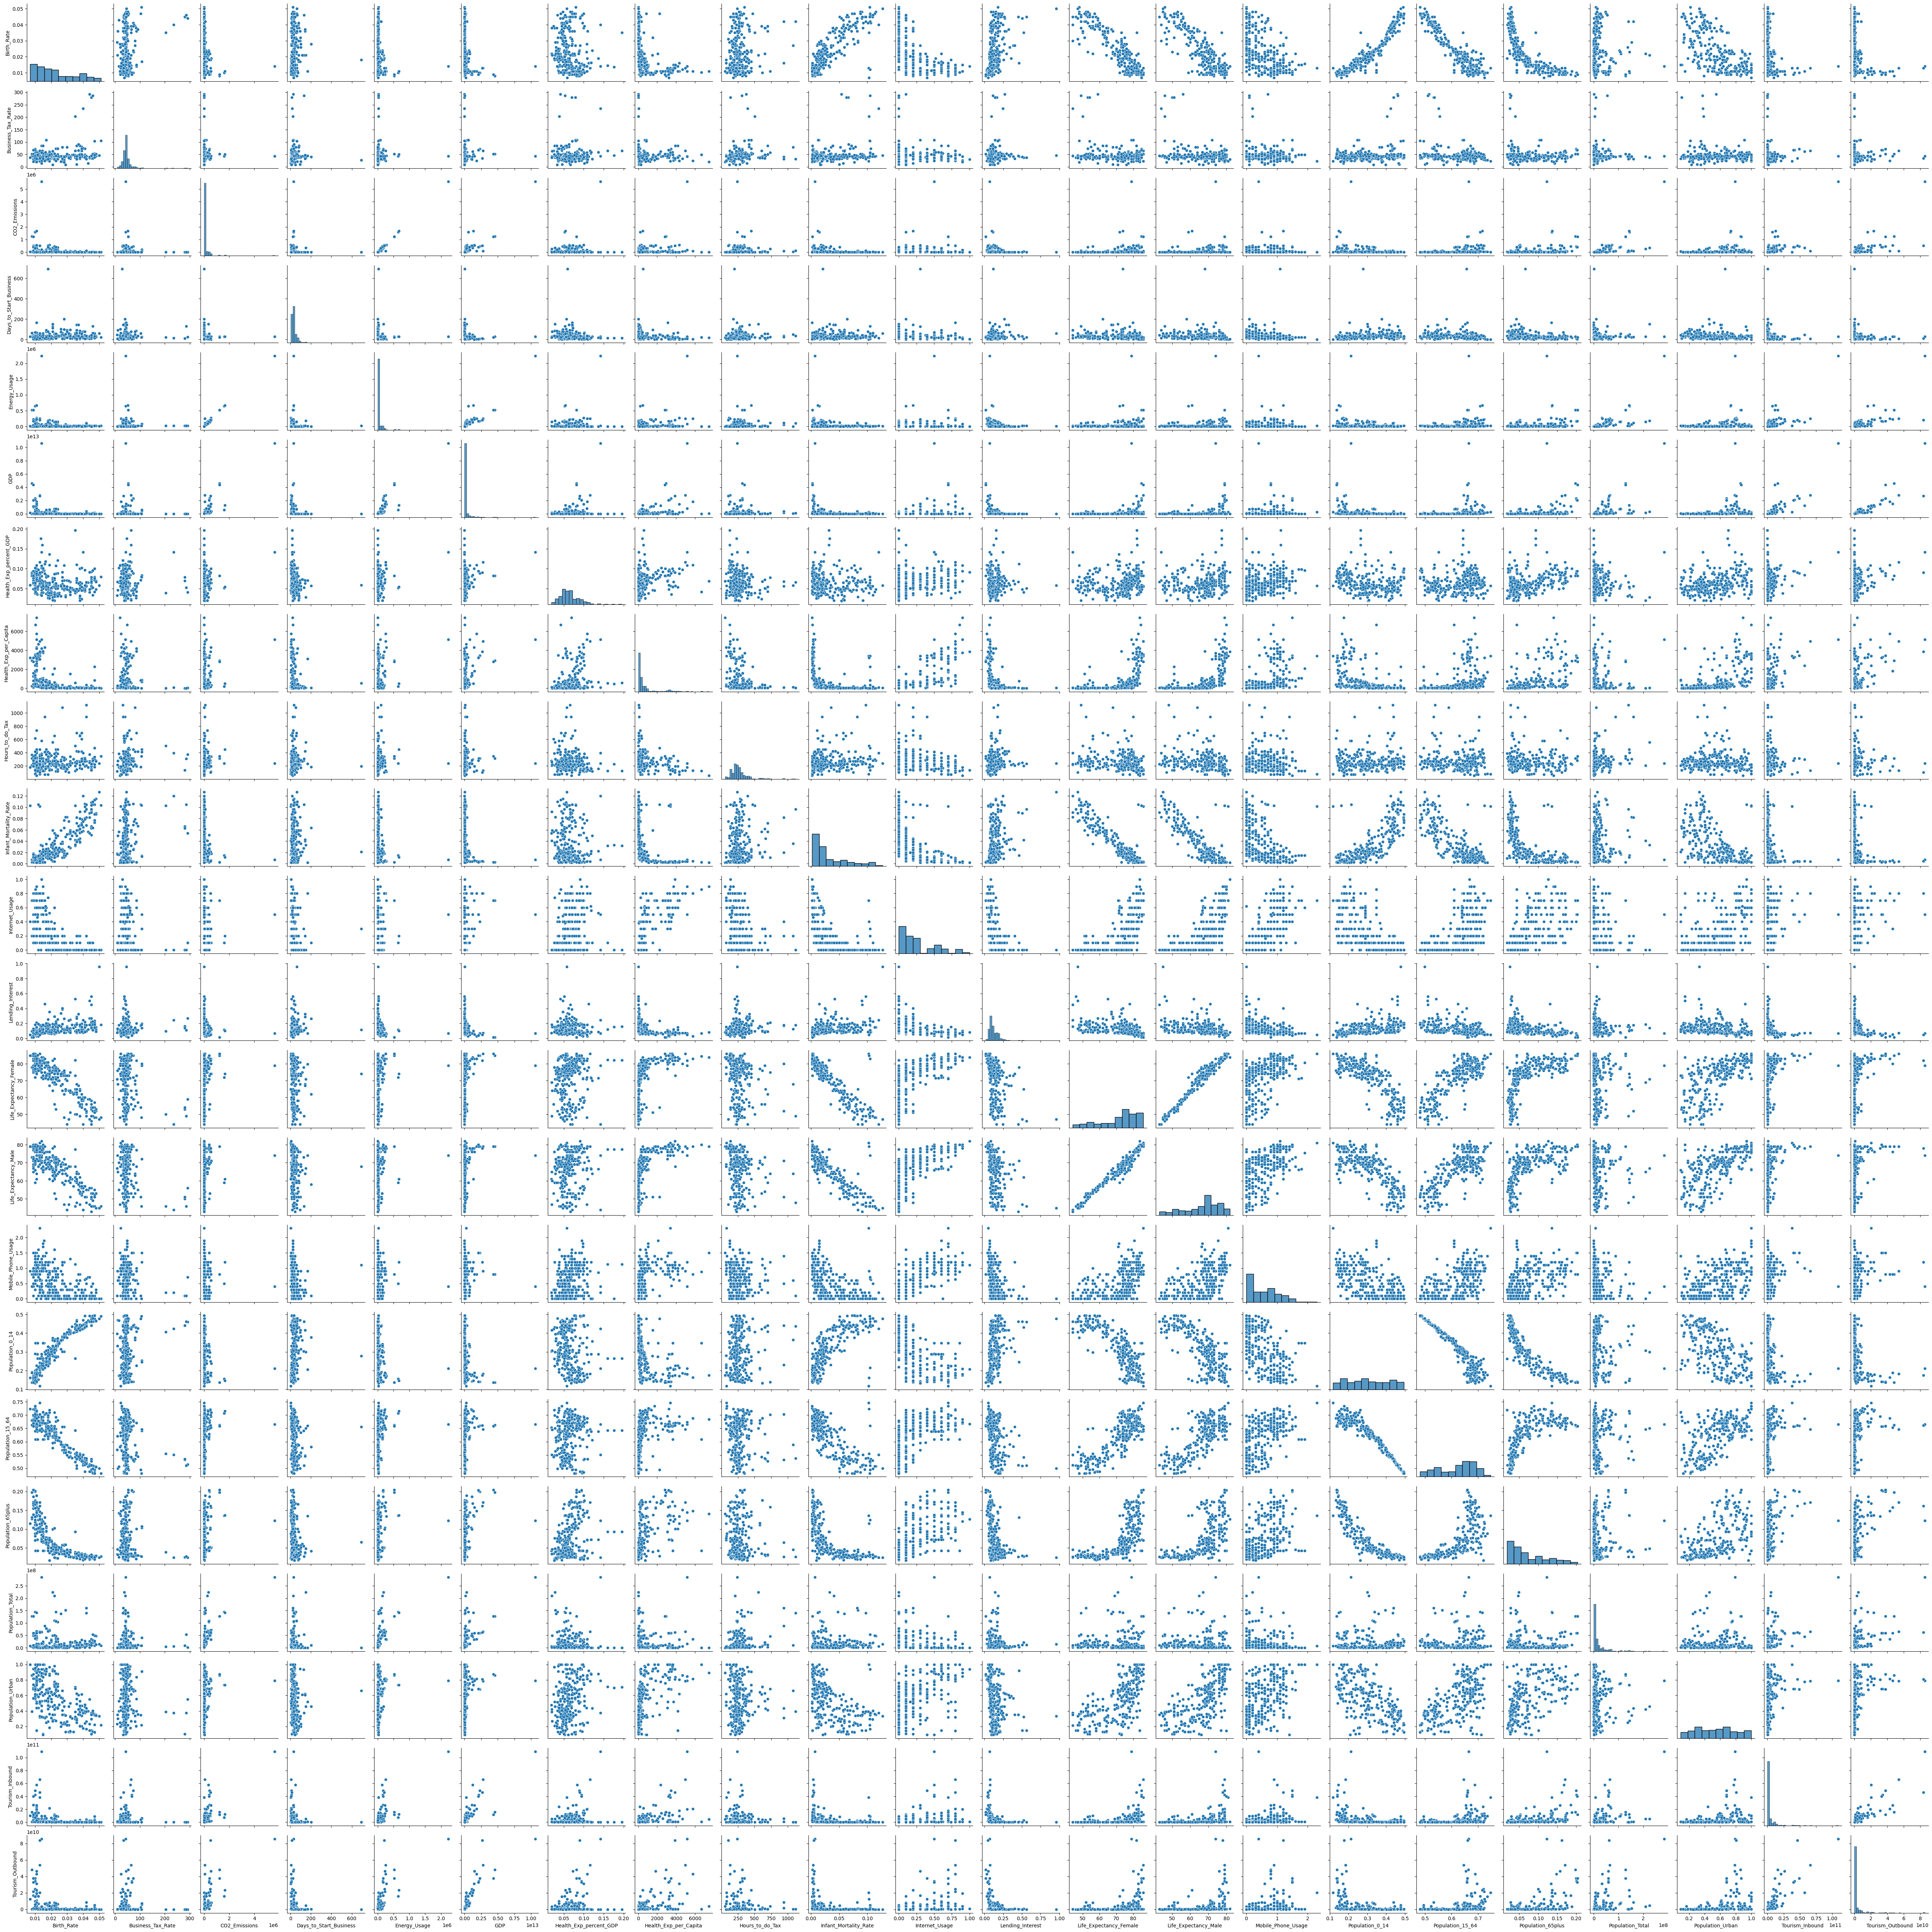

In [245]:
sns.pairplot(df_imputed.sample(300), kind='scatter')
plt.show()

In [246]:
sns.set(style="whitegrid")

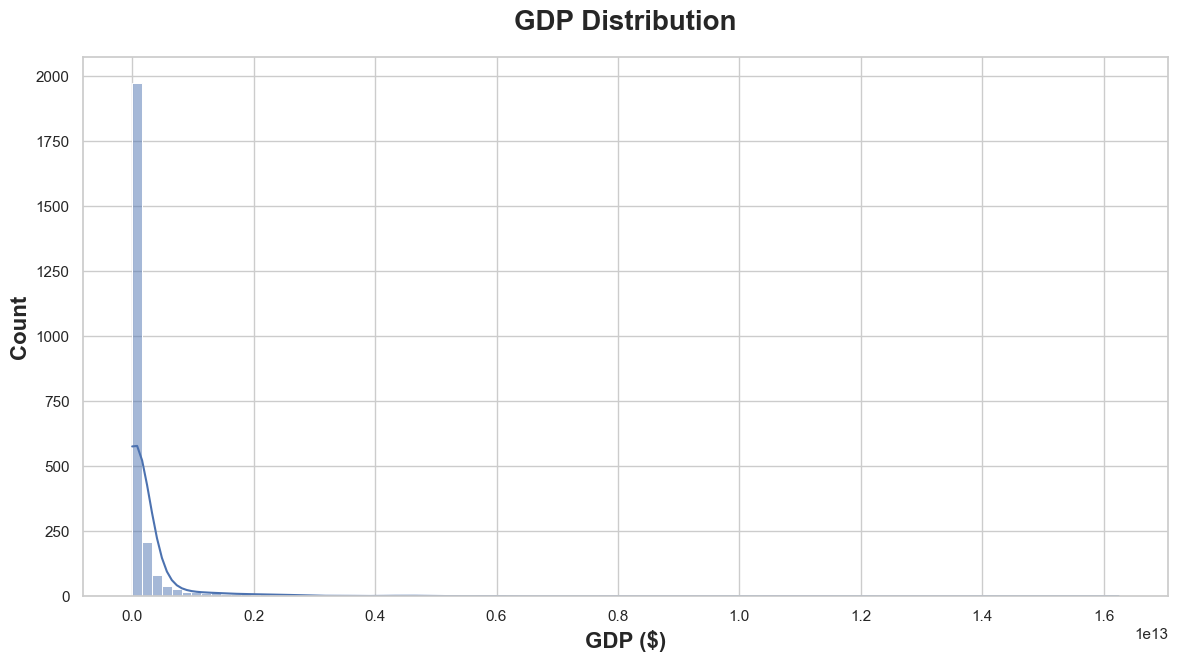

In [248]:
plt.subplots(figsize=(14,7))
sns.histplot(df['GDP'], kde=True, color='b', bins=100)
plt.title("GDP Distribution", weight='bold', fontsize=20, pad=20)
plt.xlabel('GDP ($)', weight='bold', fontsize=16)
plt.ylabel('Count', weight='bold', fontsize=16)

# Save Plot
plt.savefig('./images/GDP_Distribution.png')

<p style="background-color:#008000;color:#fff;font-size:18px;padding:10px"> Insights : </p>
<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

* The distribution is highly right skewed.
* Most countries have low GDP values. A few countries have extremely high GDP. The long tail on the right side represents large economies
* Dataset is heavily concentrated in lower GDP values.
* The GDP feature shows a highly right-skewed distribution with extreme outliers representing large economies.
* The log transformatio will be required to normalize the distribution.
    
<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

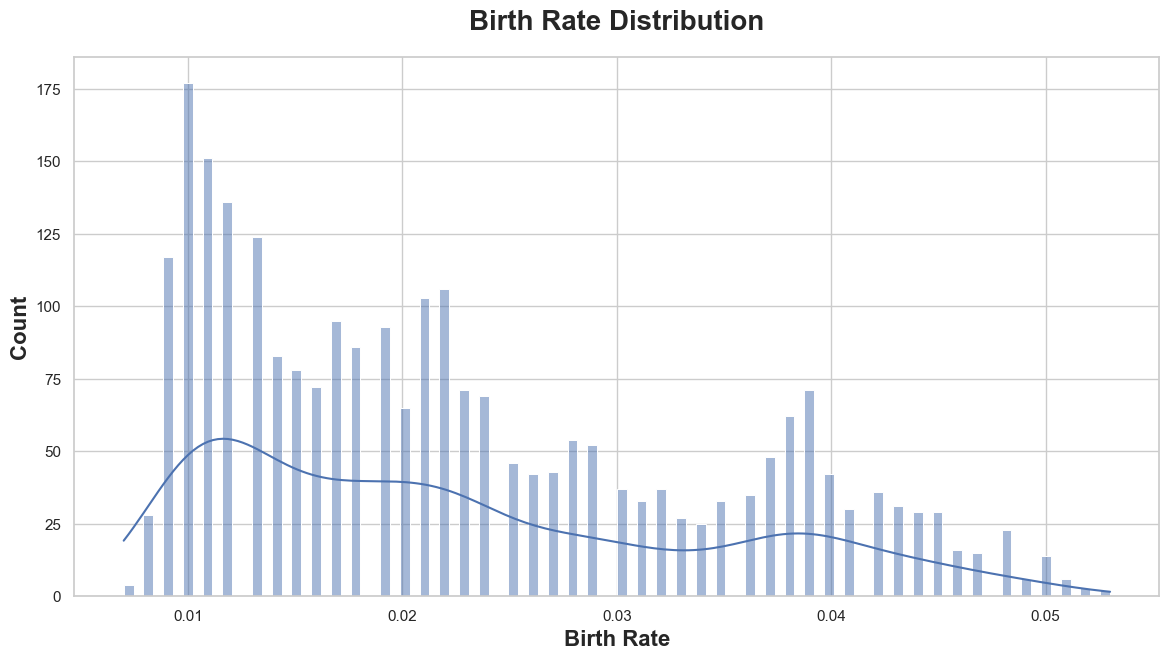

In [250]:
plt.subplots(figsize=(14,7))
sns.histplot(df['Birth_Rate'], kde=True, color='b', bins=100)
plt.title("Birth Rate Distribution", weight='bold', fontsize=20, pad=20)
plt.xlabel('Birth Rate', weight='bold', fontsize=16)
plt.ylabel('Count', weight='bold', fontsize=16)

# Save Plot
plt.savefig('./images/BirthRate_Distribution.png')

<p style="background-color:#008000;color:#fff;font-size:18px;padding:10px"> Insights : </p>
<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

* The distribution is moderately right-skewed (positive skew):
* Most countries have birth rates between 0.01 and 0.03
* Fewer countries have very high birth rates (>0.04)
* No extreme outliers present
* Mean and median are close the distribution is balanced
* Multiple peaks suggest natural groupings of countries based on demographic patterns.
    
<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

## Checking Outliers

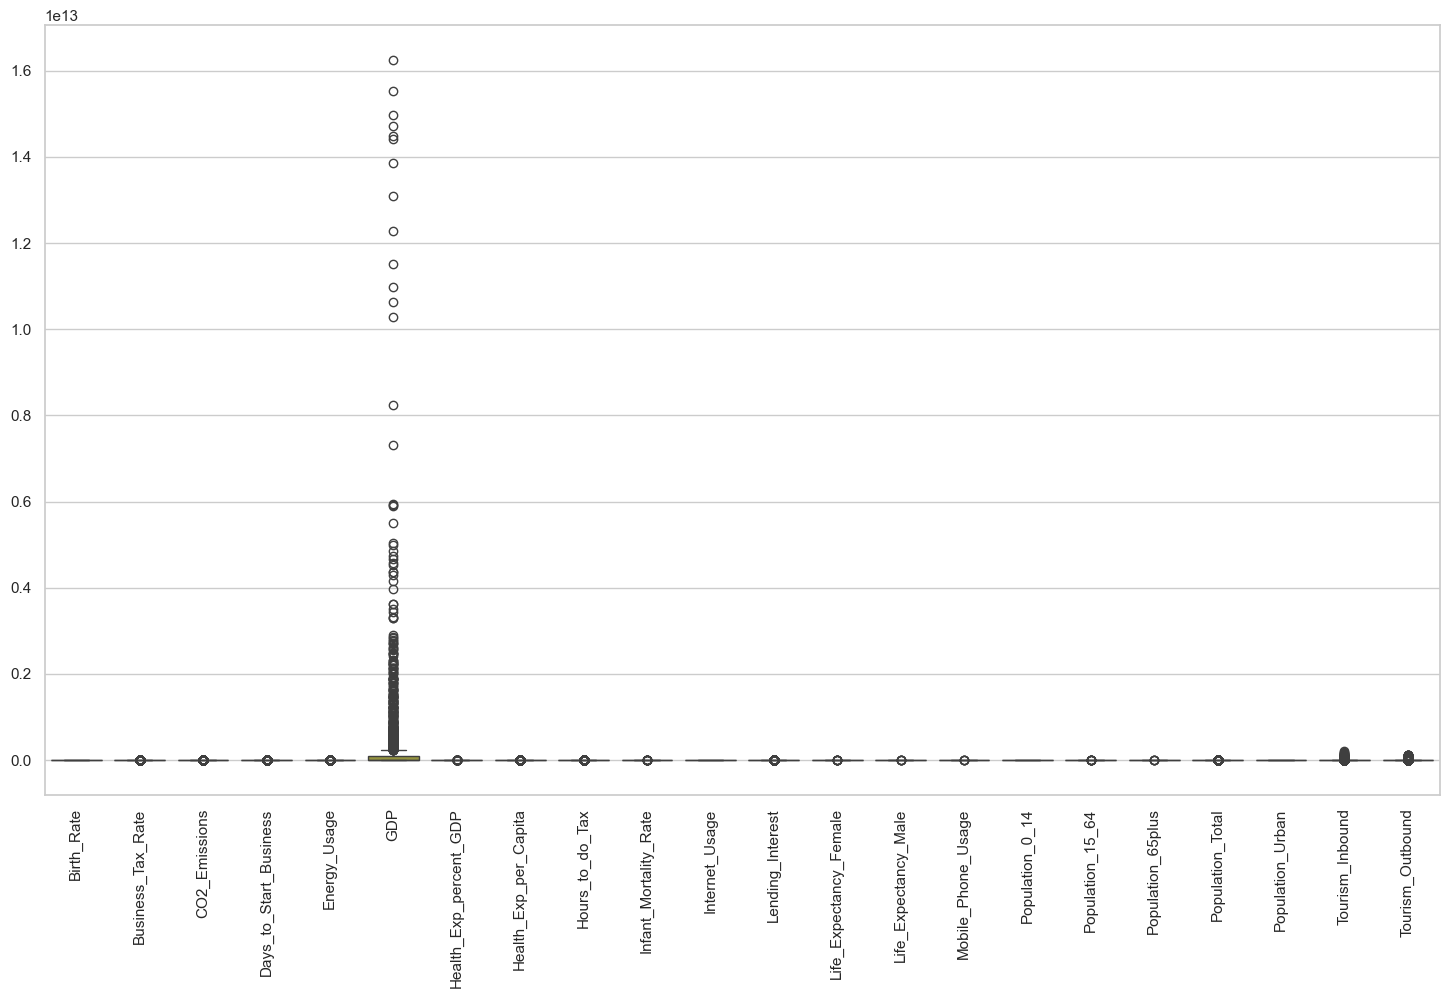

In [253]:
plt.figure(figsize=(18,10))
sns.boxplot(data=df_imputed)
plt.xticks(rotation=90)

# Save Plot
plt.savefig('./images/Outliers_boxplot.png')

<p style="background-color:#008000;color:#fff;font-size:18px;padding:10px"> Insights : </p>
<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

* The dataset contains extreme outliers in GDP, Population, Tourism, and Energy-related variables.
* This makes other features look flat near zero.
* Log Transformation is required for heavy features, to reduce outliers, make the disctribution normal
* The scaling is also required after log transformation to get the date in same range.
* We will keep outliers, as these are not errors, these are real country data  

<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

## Log Transformation for features having heavy ranges

In [254]:
log_features = [
    'GDP',
    'Population_Total',
    'CO2_Emissions',
    'Energy_Usage',
    'Tourism_Inbound',
    'Tourism_Outbound',
    'Health_Exp_per_Capita'
]

for col in log_features:
    df_imputed[col] = np.log1p(df_imputed[col])


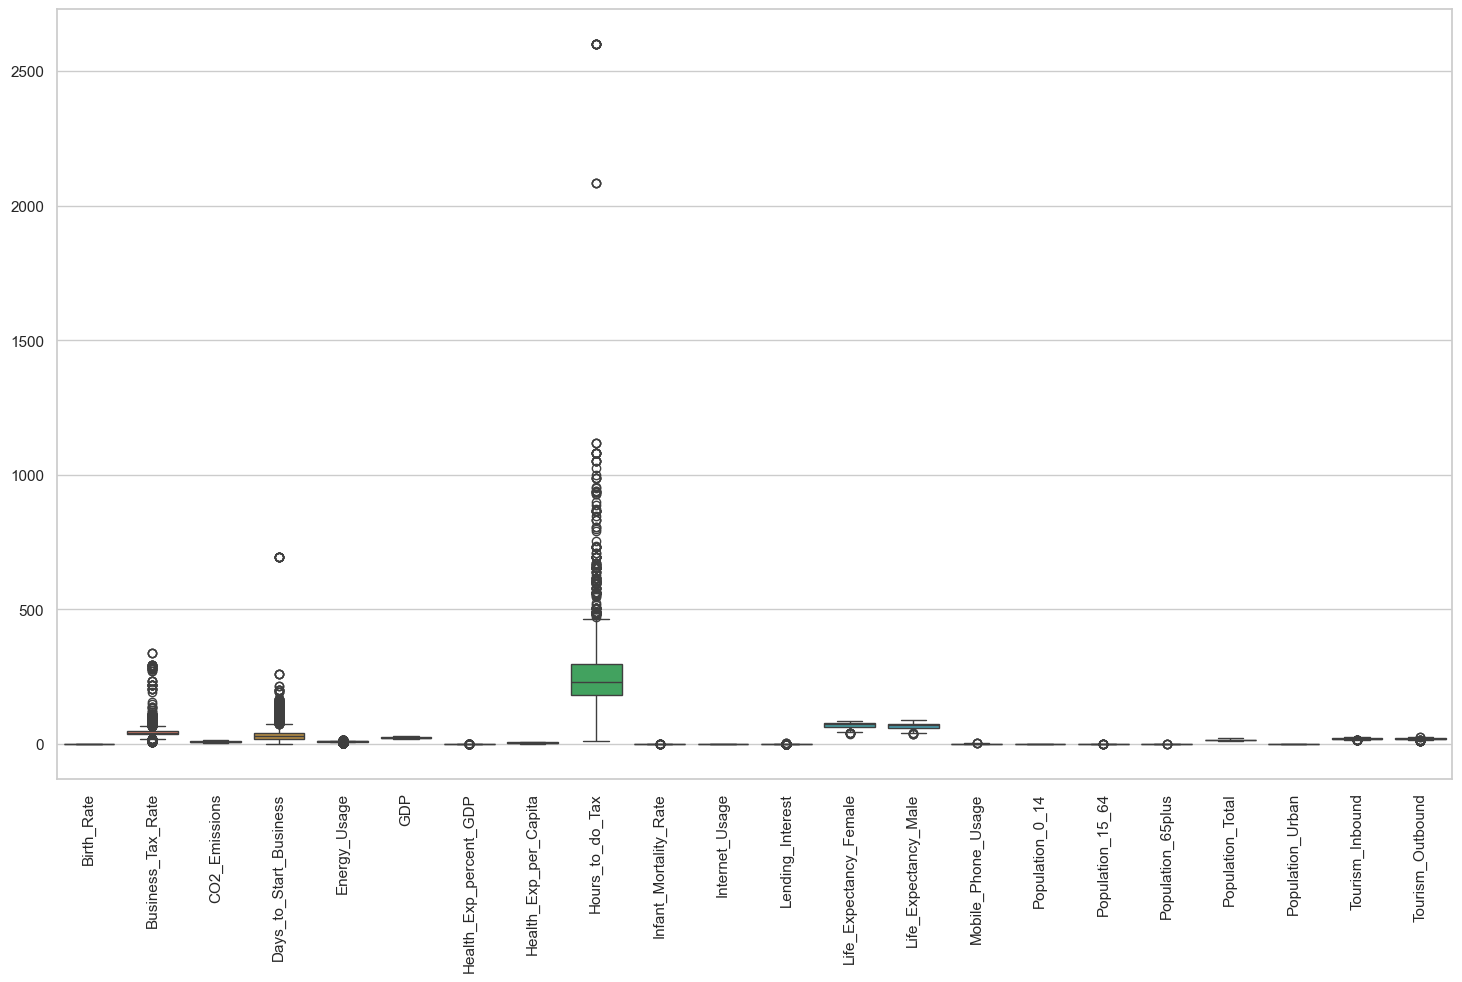

In [256]:
plt.figure(figsize=(18,10))
sns.boxplot(data=df_imputed)
plt.xticks(rotation=90)

plt.savefig('./images/Lo_transformation.png')

<p style="background-color:#008000;color:#fff;font-size:18px;padding:10px"> Insights : </p>
<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

* The log trasformation is applied to the heavy columns, reduced the outliers, and made the features normal ditributed.
* Now we will perform Standard scaling to scale the data into same range
* We can see some outliers in other features now

<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

## Standard Scaling

In [258]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_imputed)

In [259]:
X_scaled

array([[-0.20613219,  0.11131211,  1.02928332, ...,  0.13955363,
        -0.85716036, -0.3497152 ],
       [ 2.45991425, -0.11963288,  0.16907918, ..., -0.97836917,
        -1.36519642, -0.47594332],
       [ 1.83783675, -0.07564336, -0.51831424, ..., -0.73852392,
        -0.98718182, -0.9606153 ],
       ...,
       [-0.65047326, -0.18173573, -0.91211131, ...,  1.5582993 ,
         0.56768783,  0.40682982],
       [-0.20613219,  0.46516901,  0.97874808, ...,  1.31845404,
         0.15180507,  0.92070959],
       [-1.00594612, -0.02130336, -1.47579422, ...,  1.56236447,
        -0.98478579, -1.74637449]], shape=(2704, 22))

In [264]:
df_scaled = pd.DataFrame(X_scaled, columns=df_imputed.columns)

In [265]:
df_scaled.describe().T[['mean','std','min','max']]

,mean,std,min,max
Birth_Rate,-7.357691e-17,1.000185,-1.361419,2.726519
Business_Tax_Rate,-7.357691e-17,1.000185,-1.271770,9.431269
CO2_Emissions,5.649656e-16,1.000185,-2.574937,2.790113
Days_to_Start_Business,-1.576648e-17,1.000185,-0.795659,13.885281
Energy_Usage,2.181030e-16,1.000185,-3.612645,2.808278
GDP,4.940164e-16,1.000185,-2.344447,2.912896
Health_Exp_percent_GDP,-4.835054e-16,1.000185,-2.198792,6.314734
Health_Exp_per_Capita,2.102197e-17,1.000185,-2.475737,2.051479
Hours_to_do_Tax,6.832142e-17,1.000185,-1.255895,11.371721
Infant_Mortality_Rate,-1.156209e-16,1.000185,-0.976590,3.628111


In [270]:
print("Mean:", df_scaled.mean().mean())
print("Std:", df_scaled.std().mean())

Mean: -9.406139127405172e-17
Std: 1.0001849625466661


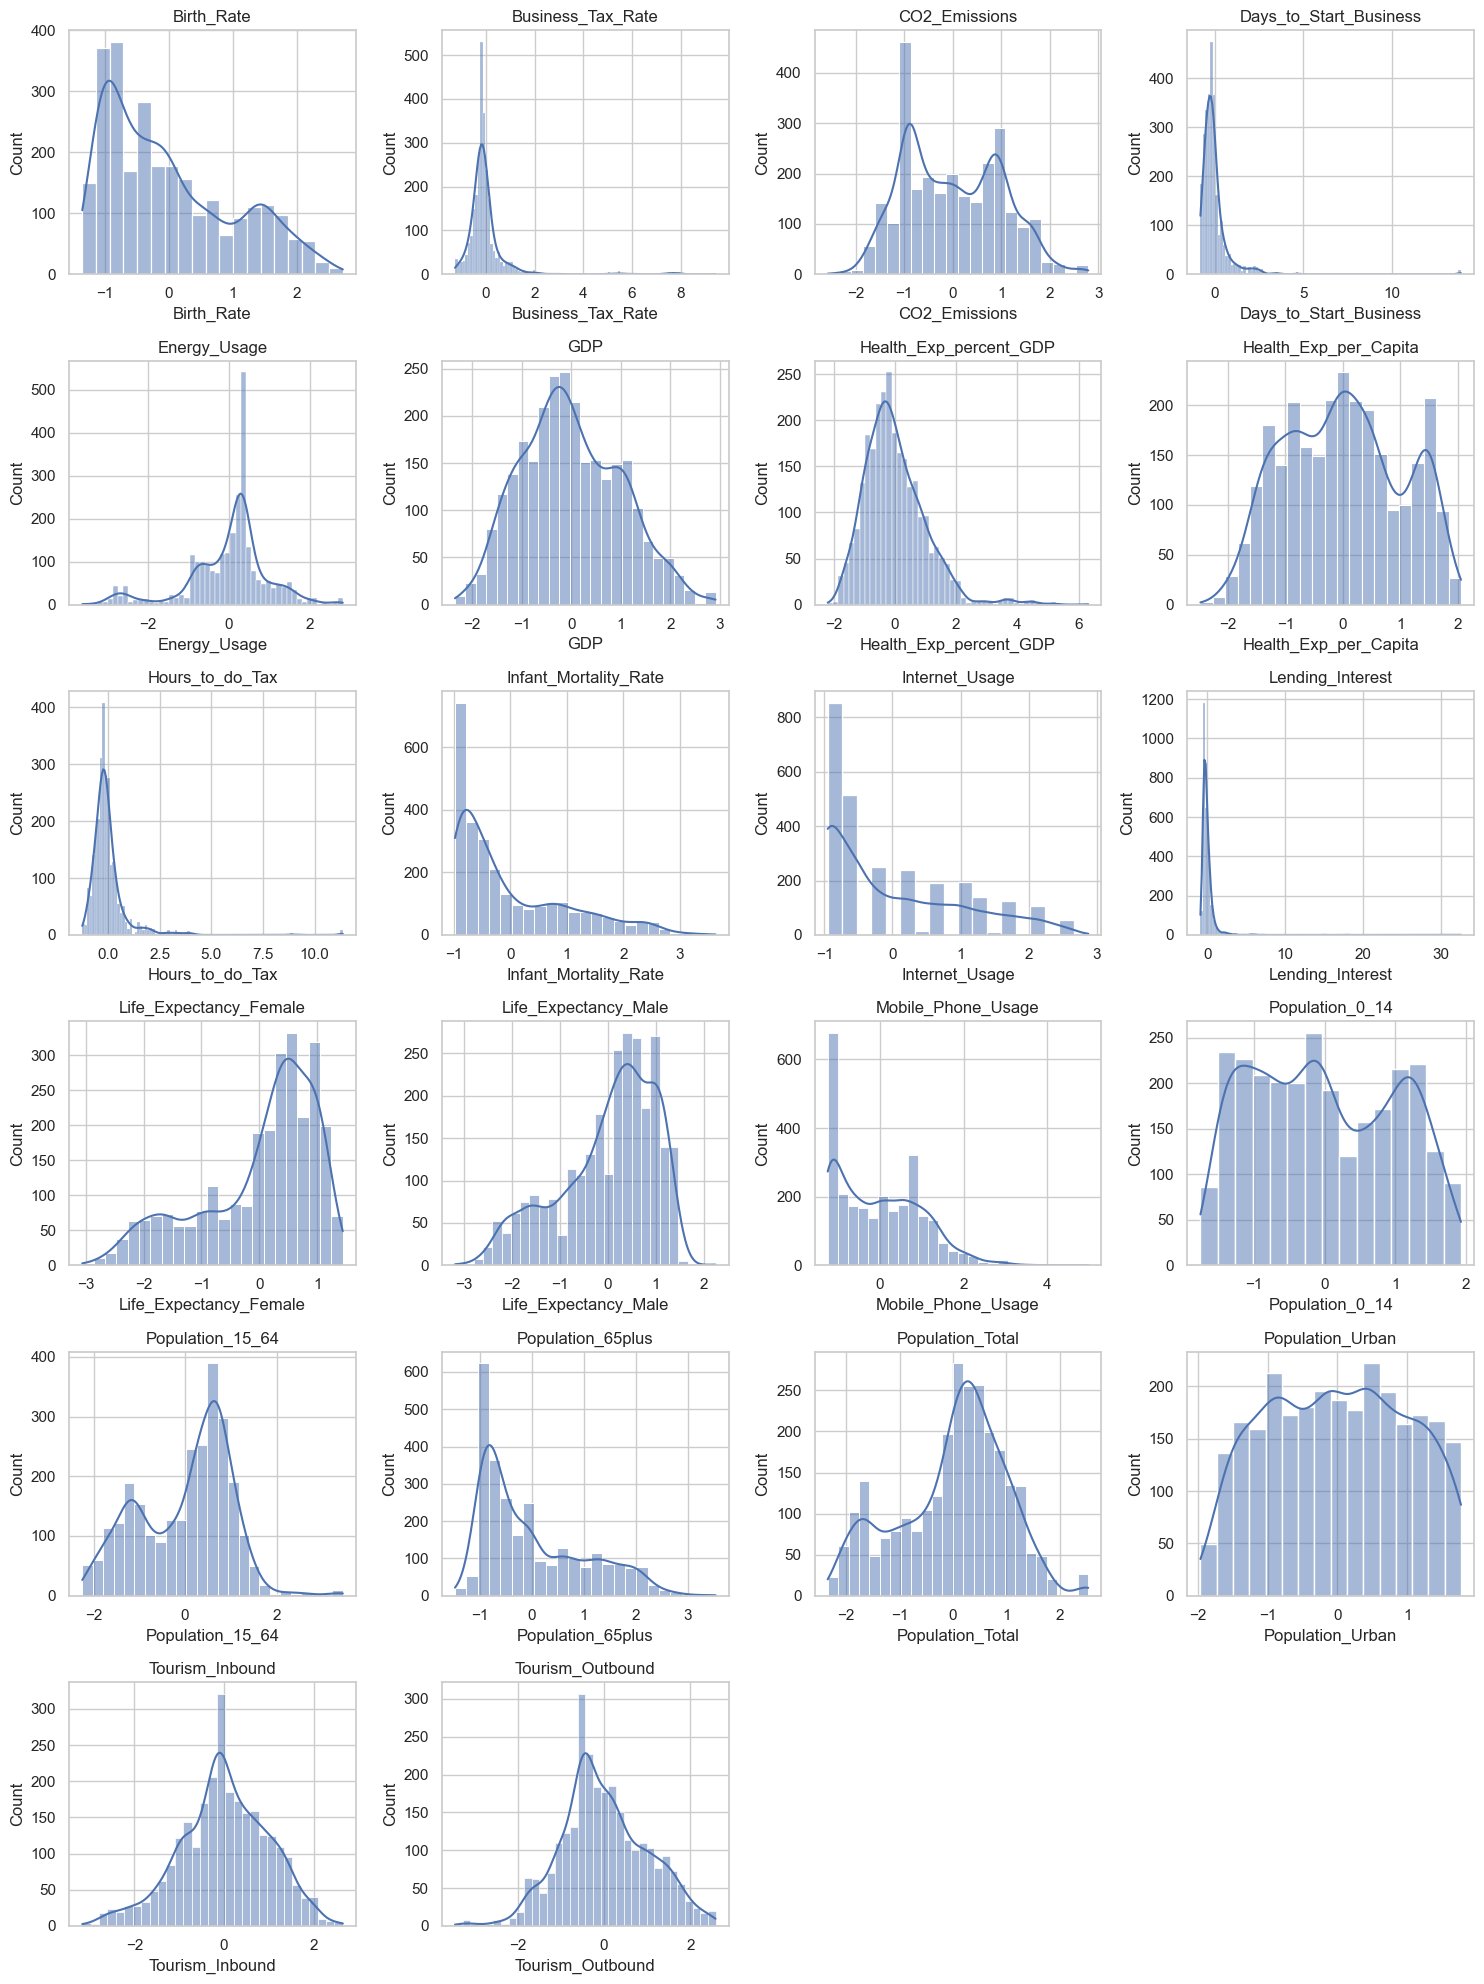

In [273]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,20))

for i, col in enumerate(df_scaled.columns):
    
    plt.subplot(6,4,i+1)
    sns.histplot(df_scaled[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.savefig('./Scaled_distribution.png')

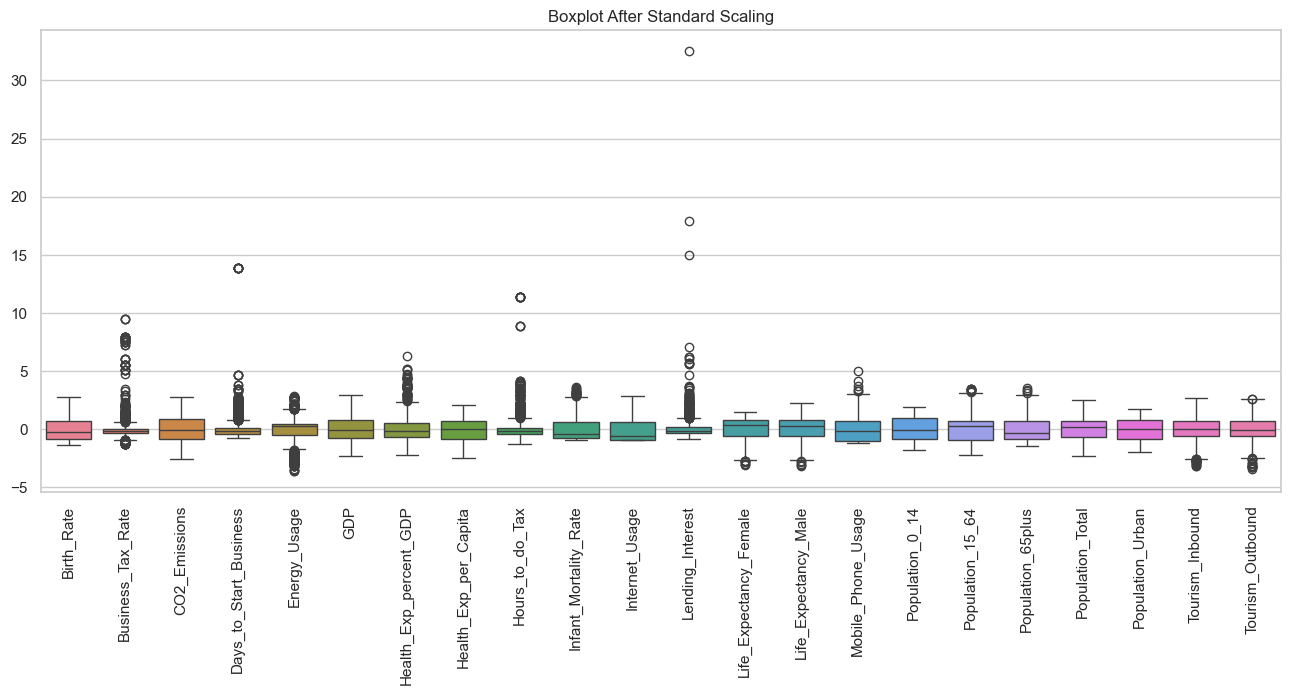

In [274]:
plt.figure(figsize=(16,6))
sns.boxplot(data=df_scaled)
plt.xticks(rotation=90)
plt.title("Boxplot After Standard Scaling")
plt.savefig('./Scaled_boxplot.png')

<p style="background-color:#008000;color:#fff;font-size:18px;padding:10px"> Insights : </p>
<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

* After applying standard scaling, we can see all features mean ~= 0 and std ~=1
* The data is normally distributed, centerd around 0 and ranges between -3 to +3
* Without treating outliers.`


<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

## Applying PCA on Scaled Data 

In [275]:
from sklearn.decomposition import PCA

pca = PCA()

pca.fit(X_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


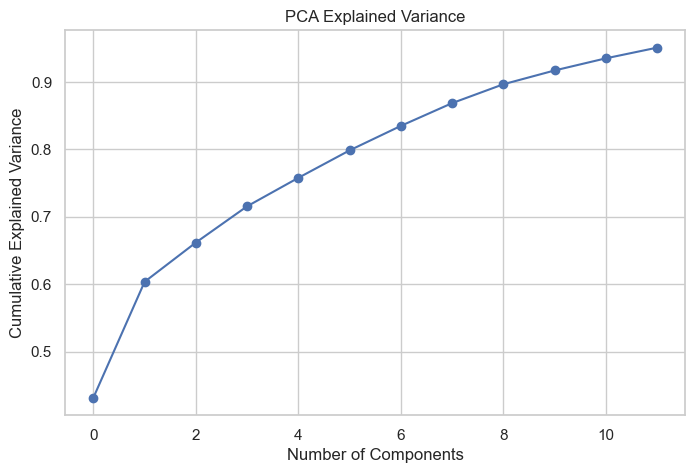

In [282]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')

plt.savefig('./images/variance_ratio.png')

In [279]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Number of Components:", pca.n_components_)

Number of Components: 12


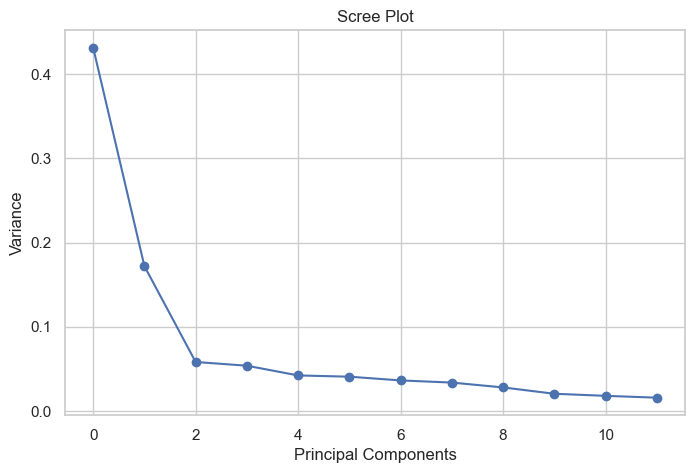

In [281]:
plt.figure(figsize=(8,5))
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.xlabel('Principal Components')
plt.ylabel('Variance')
plt.title('Scree Plot')

plt.savefig('./images/Scree_plot.png')

In [283]:
pd.DataFrame({
    'Component': range(1, len(pca.explained_variance_ratio_)+1),
    'Variance': pca.explained_variance_ratio_,
    'Cumulative': np.cumsum(pca.explained_variance_ratio_)
})

,Component,Variance,Cumulative
0,1,0.431542,0.431542
1,2,0.172023,0.603565
2,3,0.058238,0.661804
3,4,0.053798,0.715602
4,5,0.042251,0.757852
5,6,0.040770,0.798622
6,7,0.036329,0.834951
7,8,0.033768,0.868719
8,9,0.028004,0.896724
9,10,0.020490,0.917214


<p style="background-color:#008000;color:#fff;font-size:18px;padding:10px"> Insights : </p>
<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

* 12 components required to get around 95% variance.
* **We can finalize PCA with 12 components and arounf 95% variance**

<hr style="height:3px;border:none;color:#008000;background-color:#008000;">

## Applying PCA with 12 Components

In [285]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

In [286]:
print("Original Features:", X_scaled.shape[1])
print("PCA Features:", X_pca.shape[1])

Original Features: 22
PCA Features: 12


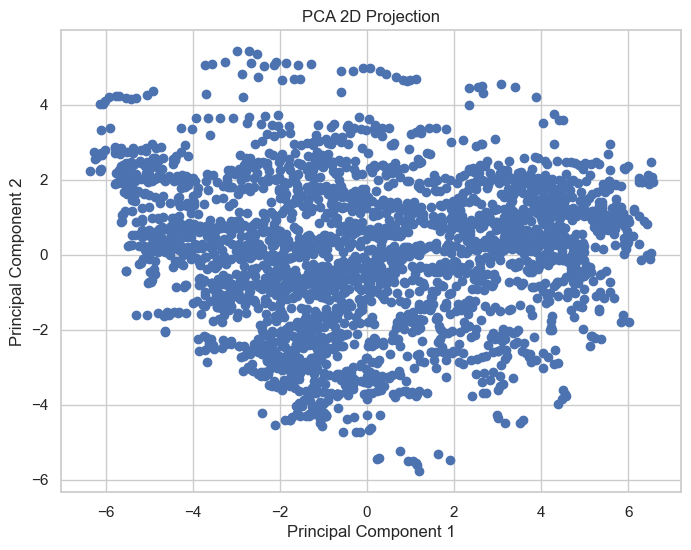

In [290]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Projection")
plt.show()